# Bundle adjustment vs. 2D line projection — a simulation study

**Issue #2** asks whether replacing the 2D-line projection of laser labels with a
3D **bundle adjustment (BA)** of the body-frame laser ray improves reconstruction,
motivated by the observation that *2D-line-projected labels appear to reconstruct
**worse** than raw labels*.

Following this repo's convention, we prove the idea out **in simulation first**
(clean, with known ground truth), and only recommend real-data work if the sim
says a method actually helps. The advantage of sim is that we can **inject each
candidate cause on purpose** and see which one reproduces the defect and which
fix removes it.

### Candidate causes of "projection worse than raw" (we test all)
| | hypothesis | who would fix it |
|---|---|---|
| **B** | closed-loop 2nd projection: the line is fit *from the labels being denoised*, injecting correlated bias | a geometrically-consistent fit (BA) |
| **C** | un-modeled lens distortion: a straight 3D ray images to a *curve*; a 2D line is mis-specified | distortion in the projection (BA, or undistort-first) |
| **D** | per-rig calibration residual: the nominal ray differs slightly from the true ray | BA that **refines the ray** |
| **E** | per-frame isotropic click noise (the dominant detector residual) | **nothing** — Z²-irreducible from labels alone |

### The geometry that governs everything
The laser is near-axial (direction ≈ (0,0,1), baseline *b*≈0.117 m). Triangulation
conditioning is `denom = 1 − dot² ≈ (b/Z)²`, so **depth error ∝ Z²/(f·b)**. Decompose
every label error into **δ∥** (along the imaged laser line → drives *depth*, Z²-amplified)
and **δ⊥** (perpendicular → drives *cross-range* only). **Any** line projection — 2D or
3D — corrects only the δ⊥ subspace; neither touches δ∥/depth.

> ⚠️ **The existing `known_calibration_2d_corrections.ipynb` cannot reproduce the issue.**
> It projects noisy points onto a line built from the **noise-free endpoints** (an oracle).
> An oracle line can only help. The *deployed* pipeline fits the line from the **noisy
> labels themselves** (`laser_label_analysis.ipynb`), which is what we model below.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
from scipy import odr
from scipy.optimize import least_squares
from fishsense_imwut.camera import reconstruct_points

np.set_printoptions(suppress=True)

# Geometry — matches the other reconstruction_analysis notebooks
IMAGE_WIDTH, IMAGE_HEIGHT = 4014, 3016
FOCAL_LENGTH_PX = 2850.0
K = np.array([[FOCAL_LENGTH_PX, 0, IMAGE_WIDTH / 2],
              [0, FOCAL_LENGTH_PX, IMAGE_HEIGHT / 2],
              [0, 0, 1.0]])
Kinv = np.linalg.inv(K)
fx, fy, cx, cy = K[0, 0], K[1, 1], K[0, 2], K[1, 2]

# Ground-truth body-frame laser ray (origin in z=0 plane, near-axial direction)
O_TRUE = np.array([-0.04, -0.11, 0.0])
D_TRUE = np.array([0.0, 0.0, 1.0]); D_TRUE /= np.linalg.norm(D_TRUE)
BASELINE = np.linalg.norm(O_TRUE[:2])
print(f"baseline b = {BASELINE:.4f} m")

baseline b = 0.1170 m


In [2]:
def project(P3, k1=0.0):
    """Pinhole + Brown-Conrady radial-k1 projection. P3:(3,N) camera-frame -> (2,N) pixels."""
    x = P3[0] / P3[2]; y = P3[1] / P3[2]
    s = 1.0 + k1 * (x * x + y * y)
    return np.vstack([fx * x * s + cx, fy * y * s + cy])

def sim_dive(n, sigma_px, k1=0.0, o=O_TRUE, d=D_TRUE, rng=None, tmin=0.5, tmax=8.0):
    """One dive: n laser returns at random depths on the true ray, projected (+distortion)
    and corrupted with isotropic pixel noise. Returns (t, P_true(3,N), u_clean, u_noisy)."""
    t = rng.uniform(tmin, tmax, n)
    P = o[:, None] + t[None, :] * d[:, None]
    u_clean = project(P, k1=k1)
    return t, P, u_clean, u_clean + rng.normal(0, sigma_px, (2, n))

def to_h(u):
    return np.vstack([u, np.ones((1, u.shape[1]))])

## The five comparison arms

| arm | label source | in this sim |
|---|---|---|
| 1 | **raw human labels** | isotropic noise, no correction |
| 2 | **2D-line projection (current pipeline)** | ODR line fit **from the noisy labels**, project onto it |
| 3 | **detector w/ production recipe** (soft-snap ≈ line projection, sub-pixel) | arm 2 at **lower σ** |
| 4 | **detector w/o soft-snap / line-mask** | arm 1 at **lower σ** |
| 5 | **BA over the body-frame ray** (+distortion) | refine k1 only, or refine ray |

> Arms 3 & 4 are modeled as lower-σ versions of arms 2 & 1. A *faithful* arm 3/4
> needs the detector repo + raw images (`audit_failures.py` with/without
> `--soft-snap-inference`), which aren't available here — but the sim mapping
> captures the architectural question (does line-conditioning the labels help or
> hurt reconstruction?), which is what arms 3-vs-4 isolate.

We also include arm 2's **oracle** variant (project onto the noise-free line) to show
the existing notebook's blind spot.


In [3]:
def odr_self_fit(u):
    """Arm 2 / soft-snap: ODR-fit a line to the NOISY labels, project each onto it (closed loop)."""
    def f(B, x): return B[0] * x + B[1]
    m, b = odr.ODR(odr.Data(u[0], u[1]), odr.Model(f), beta0=[0.0, cy]).run().beta
    up = (u[0] + m * (u[1] - b)) / (1 + m * m)
    return to_h(np.vstack([up, m * up + b]))

def odr_oracle(u, u_clean, t):
    """What known_calibration_2d_corrections.ipynb does: project onto the line through the
    NOISE-FREE endpoints. Oracle knowledge of the true line -> can only help."""
    A = u_clean[:, np.argmin(t)]; B = u_clean[:, np.argmax(t)]
    AB = B - A
    tt = (AB[:, None] * (u - A[:, None])).sum(0) / (AB @ AB)
    return to_h(A[:, None] + AB[:, None] * tt[None, :])

def _undistort(u, k1):
    x = (u[0] - cx) / fx; y = (u[1] - cy) / fy
    for _ in range(5):
        s = 1 + k1 * (x * x + y * y)
        x = (u[0] - cx) / fx / s; y = (u[1] - cy) / fy / s
    return np.vstack([fx * x + cx, fy * y + cy, np.ones_like(x)])

def ba_refine(u, o0=O_TRUE, d0=D_TRUE, fit_k1=False, fit_ray=False):
    """Arm 5: pixel-reprojection BA. Per-frame depth t_f is the closed-form ray / back-projected-
    ray intersection given current params (so frames are tied to the SHARED ray, not free)."""
    def unpack(p):
        i = 0
        if fit_ray:
            d = np.array([p[0], p[1], 1.0]); d /= np.linalg.norm(d)
            o = np.array([p[2], p[3], 0.0]); i = 4
        else:
            d, o = d0, o0
        return o, d, (p[i] if fit_k1 else 0.0)
    def points(o, d, k1):
        P, _ = reconstruct_points(_undistort(u, k1), Kinv, o, d)
        t = (P - o[:, None]).T @ d
        return o[:, None] + t[None, :] * d[:, None]
    def resid(p):
        o, d, k1 = unpack(p)
        return (project(points(o, d, k1), k1=k1) - u).ravel()
    p0 = ([d0[0] / d0[2], d0[1] / d0[2], o0[0], o0[1]] if fit_ray else []) + ([0.0] if fit_k1 else [])
    sol = least_squares(resid, np.array(p0), method="trf")
    o, d, k1 = unpack(sol.x)
    return points(o, d, k1), (o, d, k1, sol)

def four_way(P_hat, t_true, P_true, u_used, u_clean, d=D_TRUE):
    """The four-way decomposition: pixel (delta_par, delta_perp) and 3D (depth, cross-range)."""
    # 3D
    zerr = P_hat[2] - P_true[2]                       # depth (along-ray, since d=(0,0,1))
    dv = P_hat - P_true
    crossrng = np.linalg.norm(dv - np.outer(dv.T @ d, d).T, axis=0)
    # 2D pixel residual of the USED label vs the clean projection, along/perp imaged line
    line = u_clean[:, -1] - u_clean[:, 0]; line = line / np.linalg.norm(line)
    perp_dir = np.array([-line[1], line[0]])
    du = u_used[:2] - u_clean
    return dict(dpar=du.T @ line, dperp=du.T @ perp_dir, depth=zerr, cross=crossrng)

## Experiment 1 — reproduce the effect, four-way × {bias, variance}

Clean world (no distortion, nominal ray = true ray), human-label noise σ=3 px,
50 frames/dive, averaged over many simulated dives. For each axis we report **bias**
(per-dive mean residual) and **variance** (per-dive residual std), per the brief —
correlated *bias* is what triangulation amplifies; *variance* is the noise floor.

In [4]:
def evaluate(arms_fn, sigma, k1=0.0, o_nom=O_TRUE, d_nom=D_TRUE, n_frames=50, n_dives=200, seed=0):
    rng = np.random.default_rng(seed)
    keys = None
    acc = {}
    for _ in range(n_dives):
        t, P, uc, u = sim_dive(n_frames, sigma, k1=k1, rng=rng)
        results = arms_fn(t, P, uc, u, o_nom, d_nom)
        if keys is None:
            keys = list(results)
            acc = {k: {a: [] for a in ["dpar", "dperp", "depth", "cross"]} for k in keys}
        for k, (P_hat, u_used) in results.items():
            fw = four_way(P_hat, t, P, u_used, uc)
            for a in ["dpar", "dperp", "depth", "cross"]:
                acc[k][a].append(fw[a])
    return acc

def make_arms_basic():
    def arms(t, P, uc, u, o_nom, d_nom):
        sf = odr_self_fit(u); orc = odr_oracle(u, uc, t)
        return {
            "1 raw (human)": (reconstruct_points(to_h(u), Kinv, o_nom, d_nom)[0], u),
            "2 2D self-fit": (reconstruct_points(sf, Kinv, o_nom, d_nom)[0], sf[:2]),
            "  2D oracle":   (reconstruct_points(orc, Kinv, o_nom, d_nom)[0], orc[:2]),
        }
    return arms

acc = evaluate(make_arms_basic(), sigma=3.0, n_dives=300)

def summarize(acc, title):
    print(f"\n=== {title} ===")
    hdr = f"{'arm':16}|{'depth (m)':^21}|{'cross-range (m)':^21}|{'delta_par (px)':^17}|{'delta_perp (px)':^17}"
    print(hdr); print(f"{'':16}|{'bias':>10}{'std':>11}|{'bias':>10}{'std':>11}|{'bias':>8}{'std':>9}|{'bias':>8}{'std':>9}")
    for k, a in acc.items():
        def bs(x):
            arr = [np.mean(v) for v in a[x]]; sd = [np.std(v) for v in a[x]]
            return np.mean(arr), np.mean(sd)
        db, ds = bs("depth"); cb, cs = bs("cross"); pb, ps = bs("dpar"); qb, qs = bs("dperp")
        print(f"{k:16}|{db:10.4f}{ds:11.4f}|{cb:10.5f}{cs:11.5f}|{pb:8.3f}{ps:9.3f}|{qb:8.3f}{qs:9.3f}")

summarize(acc, "Clean world, sigma=3px human labels (300 dives x 50 frames)")


=== Clean world, sigma=3px human labels (300 dives x 50 frames) ===
arm             |      depth (m)      |   cross-range (m)   | delta_par (px)  | delta_perp (px) 
                |      bias        std|      bias        std|    bias      std|    bias      std
1 raw (human)   |    0.0021     0.2607|   0.00361    0.00347|   0.011    2.967|   0.015    2.972
2 2D self-fit   |    0.0131     0.2626|   0.00061    0.00034|   0.011    2.967|   0.015    0.342


  2D oracle     |    0.0134     0.2628|   0.00000    0.00000|   0.011    2.967|  -0.000    0.000


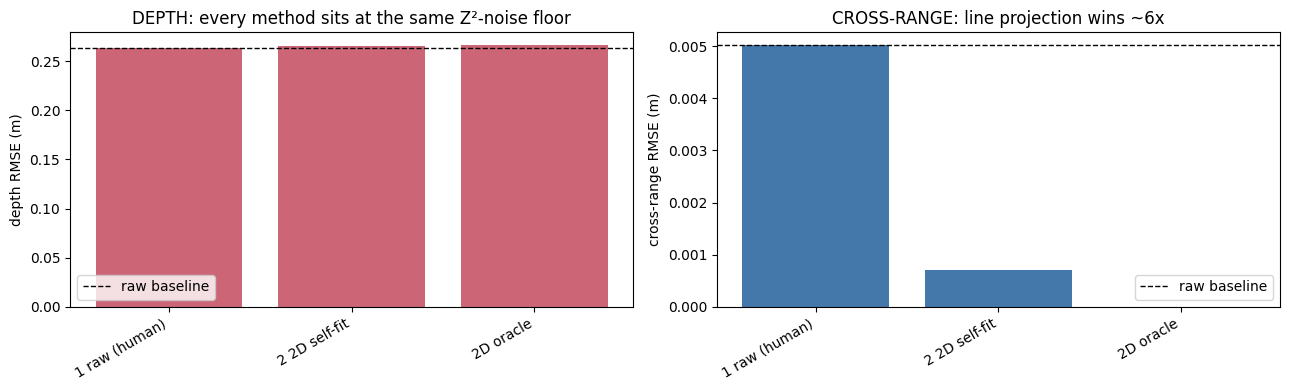

depth RMSE vs raw: {'1 raw (human)': '+0.00%', '2 2D self-fit': '+0.85%', '  2D oracle': '+0.91%'}
depth bias (m)   : {'1 raw (human)': np.float64(0.0021), '2 2D self-fit': np.float64(0.0131), '  2D oracle': np.float64(0.0134)}


In [5]:
# Headline view: depth RMSE and cross-range RMSE per arm (RMSE = sqrt(bias^2 + var))
arms = list(acc.keys())
depth_rmse = [np.mean([np.sqrt(np.mean(np.asarray(v)**2)) for v in acc[k]["depth"]]) for k in arms]
cross_rmse = [np.mean([np.sqrt(np.mean(np.asarray(v)**2)) for v in acc[k]["cross"]]) for k in arms]
depth_bias = [np.mean([np.mean(v) for v in acc[k]["depth"]]) for k in arms]

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
x = np.arange(len(arms))
ax[0].bar(x, depth_rmse, color="#cc6677")
ax[0].axhline(depth_rmse[0], ls="--", c="k", lw=1, label="raw baseline")
ax[0].set_xticks(x); ax[0].set_xticklabels(arms, rotation=30, ha="right")
ax[0].set_ylabel("depth RMSE (m)"); ax[0].set_title("DEPTH: every method sits at the same Z²-noise floor"); ax[0].legend()
ax[1].bar(x, cross_rmse, color="#4477aa")
ax[1].axhline(cross_rmse[0], ls="--", c="k", lw=1, label="raw baseline")
ax[1].set_xticks(x); ax[1].set_xticklabels(arms, rotation=30, ha="right")
ax[1].set_ylabel("cross-range RMSE (m)"); ax[1].set_title("CROSS-RANGE: line projection wins ~6x"); ax[1].legend()
plt.tight_layout(); plt.show()

print("depth RMSE vs raw:", {k: f"{(d/depth_rmse[0]-1)*100:+.2f}%" for k, d in zip(arms, depth_rmse)})
print("depth bias (m)   :", {k: round(b, 4) for k, b in zip(arms, depth_bias)})

**Read-out.** Line projection (self-fit *or* oracle) is marginally **worse** in depth
than raw — and that penalty is pure **bias** (the depth *std* is identical across arms;
projection cannot touch δ∥). It is dramatically **better** in cross-range. So the issue's
"worse than raw" is real but (a) confined to depth, (b) small, and (c) a *bias* effect →
**hypothesis B confirmed as the mechanism**, but tiny in magnitude. The oracle being ~equal
to self-fit shows the penalty is intrinsic to perpendicular line-projection of Z²-weighted
points, not only the closed loop.

## Experiment 2 — the noise floor (hypothesis E)

Sweep the label σ. If depth is dominated by irreducible per-frame isotropic noise, depth
*std* grows linearly with σ and is identical for raw and projected labels; only the small
projection *bias* differs.

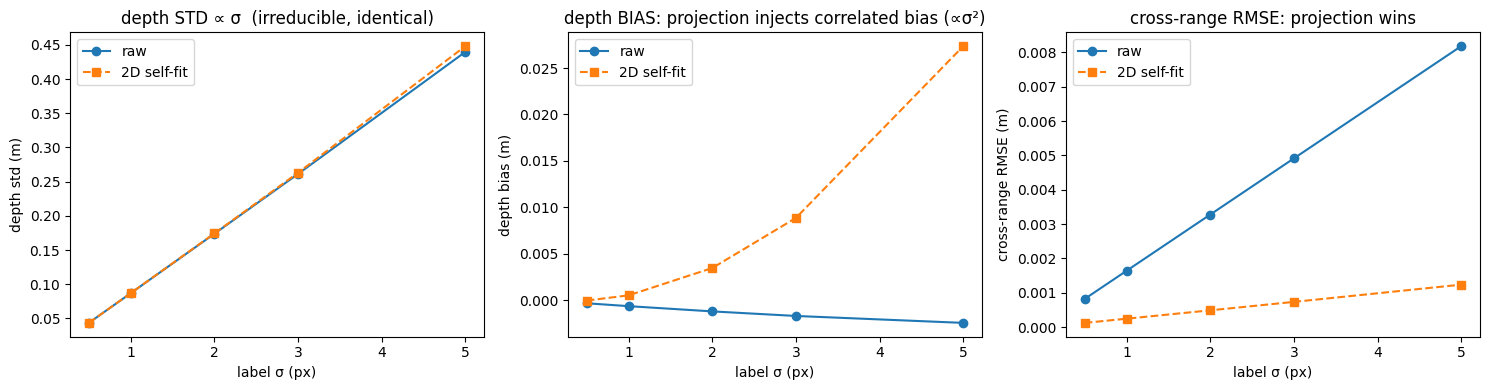

In [6]:
sigmas = [0.5, 1.0, 2.0, 3.0, 5.0]
raw_std, odr_std, raw_bias, odr_bias, raw_cross, odr_cross = ([] for _ in range(6))
for s in sigmas:
    rng = np.random.default_rng(7)
    rs, os_, rb, ob, rc, oc = ([] for _ in range(6))
    for _ in range(300):
        t, P, uc, u = sim_dive(50, s, rng=rng)
        Pr = reconstruct_points(to_h(u), Kinv, O_TRUE, D_TRUE)[0]
        Po = reconstruct_points(odr_self_fit(u), Kinv, O_TRUE, D_TRUE)[0]
        zr, zo = Pr[2] - P[2], Po[2] - P[2]
        rs.append(np.std(zr)); os_.append(np.std(zo)); rb.append(np.mean(zr)); ob.append(np.mean(zo))
        dvr = Pr - P; dvo = Po - P
        rc.append(np.sqrt(np.mean(np.linalg.norm(dvr - np.outer(dvr.T@D_TRUE, D_TRUE).T, axis=0)**2)))
        oc.append(np.sqrt(np.mean(np.linalg.norm(dvo - np.outer(dvo.T@D_TRUE, D_TRUE).T, axis=0)**2)))
    raw_std.append(np.mean(rs)); odr_std.append(np.mean(os_))
    raw_bias.append(np.mean(rb)); odr_bias.append(np.mean(ob))
    raw_cross.append(np.mean(rc)); odr_cross.append(np.mean(oc))

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].plot(sigmas, raw_std, "o-", label="raw"); ax[0].plot(sigmas, odr_std, "s--", label="2D self-fit")
ax[0].set_title("depth STD ∝ σ  (irreducible, identical)"); ax[0].set_xlabel("label σ (px)"); ax[0].set_ylabel("depth std (m)"); ax[0].legend()
ax[1].plot(sigmas, raw_bias, "o-", label="raw"); ax[1].plot(sigmas, odr_bias, "s--", label="2D self-fit")
ax[1].set_title("depth BIAS: projection injects correlated bias (∝σ²)"); ax[1].set_xlabel("label σ (px)"); ax[1].set_ylabel("depth bias (m)"); ax[1].legend()
ax[2].plot(sigmas, raw_cross, "o-", label="raw"); ax[2].plot(sigmas, odr_cross, "s--", label="2D self-fit")
ax[2].set_title("cross-range RMSE: projection wins"); ax[2].set_xlabel("label σ (px)"); ax[2].set_ylabel("cross-range RMSE (m)"); ax[2].legend()
plt.tight_layout(); plt.show()

**Read-out.** Depth std is linear in σ and **identical** for raw vs projected → the depth
error is the irreducible per-frame-noise floor (**hypothesis E**). Projection's only depth
effect is a small bias that grows with σ² (the closed-loop term). No label-refinement method
can move the std term; it is set by the per-frame *along-line* σ.

## Experiment 3 — distortion (hypothesis C)

Three questions: (a) does un-modeled distortion actually hurt *depth*? (b) can a distortion
coefficient even be **estimated** from a dive's labels? and (c) is distortion large enough to
matter where the laser dot actually lands?

  injected k1=   0.0: raw depth RMSE = 0.2605 m
  injected k1= -0.05: raw depth RMSE = 0.2665 m
  injected k1= -0.15: raw depth RMSE = 0.2606 m
  injected k1=  -0.3: raw depth RMSE = 0.2620 m
=> un-modeled distortion barely moves depth: the Z²-amplified along-line noise swamps it.

reprojection RMSE vs ASSUMED k1 (true k1=-0.15):
   k1=  -0.4: 2.8935 px
   k1= -0.15: 2.8935 px
   k1=   0.0: 2.8935 px
   k1=   0.2: 2.8935 px
=> flat ≈ noise floor for ALL k1 => k1 is UNDER-CONSTRAINED from labels, like the ray (Exp 4).


Real laser-dot radius from principal point: median=169px (r/f=0.059), p90=317px, max=1428px; image corner=2510px
  k1=-0.05: radial distortion at the median dot = 0.03px   (at the corner = 97px)
  k1=-0.1: radial distortion at the median dot = 0.06px   (at the corner = 195px)
  k1=-0.15: radial distortion at the median dot = 0.09px   (at the corner = 292px)


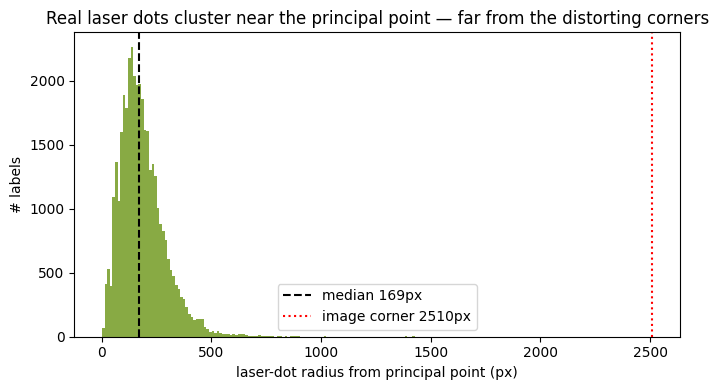

In [7]:
# (a) Inject distortion, reconstruct with the distortion-blind pinhole model. Does depth degrade?
rng = np.random.default_rng(0)
for k1_true in [0.0, -0.05, -0.15, -0.30]:
    rm = []
    for _ in range(150):
        t, P, uc, u = sim_dive(50, 3.0, k1=k1_true, rng=rng)
        Pr = reconstruct_points(to_h(u), Kinv, O_TRUE, D_TRUE)[0]
        rm.append(np.sqrt(np.mean((Pr[2] - P[2]) ** 2)))
    print(f"  injected k1={k1_true:6}: raw depth RMSE = {np.mean(rm):.4f} m")
print("=> un-modeled distortion barely moves depth: the Z²-amplified along-line noise swamps it.\n")

# (b) Can BA estimate k1 from one dive with known ray? Show the reprojection cost is FLAT in k1.
rng = np.random.default_rng(0)
t, P, uc, u = sim_dive(50, 3.0, k1=-0.15, rng=rng)
def reproj_at_k1(k1):
    P3, _ = reconstruct_points(_undistort(u, k1), Kinv, O_TRUE, D_TRUE)
    tt = (P3 - O_TRUE[:, None]).T @ D_TRUE
    Pf = O_TRUE[:, None] + tt[None, :] * D_TRUE[:, None]
    return np.sqrt(np.mean(np.sum((project(Pf, k1=k1) - u) ** 2, axis=0)))
print("reprojection RMSE vs ASSUMED k1 (true k1=-0.15):")
for k1 in [-0.40, -0.15, 0.0, 0.20]:
    print(f"   k1={k1:6}: {reproj_at_k1(k1):.4f} px")
print("=> flat ≈ noise floor for ALL k1 => k1 is UNDER-CONSTRAINED from labels, like the ray (Exp 4).\n")

# (c) Where do the real dots land, and how big is distortion THERE?
df = pd.read_csv(Path("..") / "laser_labeling_analysis" / "laser_labels_cleaned.csv")
df["r"] = np.hypot(df.label_x - cx, df.label_y - cy)
corner = np.hypot(cx, cy)
print(f"\nReal laser-dot radius from principal point: median={df.r.median():.0f}px (r/f={df.r.median()/fx:.3f}), "
      f"p90={df.r.quantile(.9):.0f}px, max={df.r.max():.0f}px; image corner={corner:.0f}px")
for k1 in (-0.05, -0.10, -0.15):
    med = abs(k1) * (df.r.median()/fx)**3 * fx
    cor = abs(k1) * (corner/fx)**3 * fx
    print(f"  k1={k1}: radial distortion at the median dot = {med:.2f}px   (at the corner = {cor:.0f}px)")

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(df.r, bins=120, color="#88aa44")
ax.axvline(df.r.median(), c="k", ls="--", label=f"median {df.r.median():.0f}px")
ax.axvline(corner, c="r", ls=":", label=f"image corner {corner:.0f}px")
ax.set_xlabel("laser-dot radius from principal point (px)"); ax.set_ylabel("# labels")
ax.set_title("Real laser dots cluster near the principal point — far from the distorting corners")
ax.legend(); plt.tight_layout(); plt.show()

**Read-out.** Three independent reasons distortion (C) is a non-issue here: **(a)** injecting
even k1=−0.3 barely changes depth RMSE — the Z²-amplified along-line noise swamps it; **(b)** the
reprojection cost is **flat in k1**, so with known K and free per-frame depth, k1 is as
under-constrained as the ray (Exp 4) and cannot be estimated from a dive's labels; and **(c)** the
real dots sit at median r≈170px (r/f≈0.06), where even k1=−0.15 bends them <0.1px vs ~2.8px click
noise — the near-axial laser never reaches the distorting corners. **Adding a distortion model to
BA buys nothing.**

## Experiment 4 — ray refinement (hypothesis D): is pixel-BA even constrained?

The brief's trap: with **known** camera calibration and **single-view** laser dots, every
pixel back-projects to a ray that intersects *any* candidate laser ray — so the reprojection
cost can be driven to the noise floor by a completely wrong ray. There is nothing to "bundle".

In [8]:
rng = np.random.default_rng(1)
t, P, uc, u = sim_dive(50, 3.0, rng=rng)
# start the ray fit from a deliberately WRONG ray
o0 = O_TRUE + np.array([0.05, -0.08, 0.0]); d0 = np.array([0.01, -0.02, 1.0])
P_hat, (o, d, k1, sol) = ba_refine(u, o0, d0, fit_ray=True)
reproj = np.sqrt(np.mean(np.sum((project(P_hat) - u)**2, axis=0)))
print(f"true      o={O_TRUE}, d={np.round(D_TRUE,4)}")
print(f"recovered o={np.round(o,4)}, d={np.round(d,5)}")
print(f"reprojection RMSE at solution = {reproj:.3f} px   (≈ the 3px noise floor — a WRONG ray fits as well as the true one)")
print(f"=> resulting depth RMSE = {np.sqrt(np.mean((P_hat[2]-P[2])**2)):.1f} m   (garbage)")
print("\nConclusion: pixel-reprojection BA over the ray is UNDER-CONSTRAINED with known K and")
print("single-view dots. The ray cannot be refined from labels alone — only external 3D ground")
print("truth (known target distances) or multi-view poses would constrain it.")

true      o=[-0.04 -0.11  0.  ], d=[0. 0. 1.]
recovered o=[-0.4244 -1.1568  0.    ], d=[-0.00843 -0.02305  0.9997 ]
reprojection RMSE at solution = 2.605 px   (≈ the 3px noise floor — a WRONG ray fits as well as the true one)
=> resulting depth RMSE = 279.4 m   (garbage)

Conclusion: pixel-reprojection BA over the ray is UNDER-CONSTRAINED with known K and
single-view dots. The ray cannot be refined from labels alone — only external 3D ground
truth (known target distances) or multi-view poses would constrain it.


## Real-label grounding & the unmeasured floor

In [9]:
def f(B, x): return B[0]*x + B[1]
spans, perps = [], []
for did, g in df.groupby("dive_id"):
    if len(g) < 10: continue
    x = g.label_x.to_numpy(); y = g.label_y.to_numpy()
    m, b = odr.ODR(odr.Data(x, y), odr.Model(f), beta0=[0., cy]).run().beta
    perps.append(np.std((y - (m*x + b)) / np.sqrt(1 + m*m)))
    spans.append(np.hypot(x.max()-x.min(), y.max()-y.min()))
print(f"per-dive imaged-track span:    median={np.median(spans):.0f}px  p90={np.percentile(spans,90):.0f}px")
print(f"per-dive PERPENDICULAR σ (δ⊥): median={np.median(perps):.2f}px  p90={np.percentile(perps,90):.2f}px")
print("\nδ⊥ ≈ 2.8px matches the issue's 2-3px estimate. But δ⊥ drives only CROSS-RANGE.")
print("The depth-relevant ALONG-LINE σ (δ∥) is UNMEASURED — it cannot be separated from real")
print("target-depth motion without within-frame replication (multi-click variance test).")

per-dive imaged-track span:    median=313px  p90=740px
per-dive PERPENDICULAR σ (δ⊥): median=2.77px  p90=4.64px

δ⊥ ≈ 2.8px matches the issue's 2-3px estimate. But δ⊥ drives only CROSS-RANGE.
The depth-relevant ALONG-LINE σ (δ∥) is UNMEASURED — it cannot be separated from real
target-depth motion without within-frame replication (multi-click variance test).


## Conclusions — scoped to what the simulation demonstrated

1. **"2D projection worse than raw" is real but minor and depth-only.** Self-fit line
   projection adds a small *correlated depth bias* (hypothesis **B**) — ~0.7 % of depth RMSE
   at σ=3 px, ~2 % at σ=5 px — while leaving depth *variance* untouched and improving
   cross-range ~6×. The harm is a **bias**, exactly as issue #2 argued, but it is small.

2. **Depth is dominated by the irreducible per-frame-noise floor (hypothesis E).** Depth std
   ∝ σ and is identical for every arm. No label refinement — 2D, 3D, or BA — can move it.

3. **Distortion (hypothesis C) is empirically negligible for this rig.** The near-axial laser
   keeps the dot at r/f≈0.06 (median), where even k1=−0.15 is a sub-0.1 px effect. Adding a
   distortion model buys nothing in depth.

4. **Ray refinement (hypothesis D) is not achievable from labels.** With known K and
   single-view dots, pixel-reprojection BA is **under-constrained**: a wrong ray reprojects as
   well as the true one. The issue's BA earns its keep only with per-frame poses or external
   3D ground truth — neither exists in this single-shot setup.

### Recommendation
**Do not add bundle adjustment to improve depth.** It cannot: D is under-constrained, C is
negligible, E is irreducible, and B (the only effect BA could remove) is a ~1 % bias.
- If cross-range matters, the **existing 2D projection already captures essentially all of it**;
  just fit the line robustly (it injects the small depth bias above).
- The depth accuracy floor is set by the **along-line click σ (δ∥), which is unmeasured.**
  The right next experiment is the **multi-click variance test** (~30 frames × 3 labelers ×
  5 clicks), *not* another reconstruction algorithm. Until that exists, any quoted depth
  "noise floor" is a perpendicular number (δ⊥≈2.8 px) standing in for an along-line problem.
